# Wetland Classification Pipeline

Interactive notebook for training and evaluating the U-Net wetland classifier.

## Workflow
1. **Setup** - Configure paths and parameters
2. **Compute Statistics** - Scan training data for normalization stats
3. **Explore Data** - Visualize samples and class distribution
4. **Train Model** - Run training loop
5. **Evaluate** - Test set metrics and confusion matrix
6. **Predict** - Apply to new rasters

## 1. Setup

In [29]:
# Imports
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
import torch

# Helper to import modules with numeric prefixes
# Checks sys.modules first to avoid duplicate imports (which break pickling)
def import_module(name, path):
    if name in sys.modules:
        return sys.modules[name]
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Get script directory
SCRIPT_DIR = Path.cwd()
if SCRIPT_DIR.name != "DL_Pipeline_v2":
    SCRIPT_DIR = Path.cwd() / "Python_Code_Analysis" / "DL_Pipeline_v2"

# Add script dir to path for band_utils import
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

# Project root
PROJECT_ROOT = SCRIPT_DIR.parent.parent

print(f"Script directory: {SCRIPT_DIR}")
print(f"Project root: {PROJECT_ROOT}")

Script directory: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Python_Code_Analysis/DL_Pipeline_v2
Project root: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL


In [30]:
# === CONFIGURATION ===
# Edit these paths and parameters as needed

# Data paths
PATCHES_DIR = PROJECT_ROOT / "Data" / "Training_Data" / "R_Patches" # Changing this to include patches without open water
STATS_PATH = PROJECT_ROOT / "Data" / "Training_Data" / "normalization_stats.json"
MODELS_DIR = PROJECT_ROOT / "Models"

# Training parameters
EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
BASE_FILTERS = 32  # 32 for local (M1), 64 for HPC
DEPTH = 4          # 4 for local, 5 for HPC
NUM_WORKERS = 4    # Set to 0 if issues on Mac
SEED = 420

# Architecture: "unet" or "resunet34"
ARCHITECTURE = "unet"

# Loss parameters
CE_WEIGHT = 0.5         # Weight for Focal Loss component (default: 0.5)
DICE_WEIGHT = 2.0       # Weight for Dice Loss component (default: 1.0)
FOCAL_GAMMA = 2.0       # Focal Loss gamma (0=plain CE, 2=standard focal)
LABEL_SMOOTHING = 0.0   # Label smoothing factor (0.0 = off)

# Classification mode: "multiclass" (5-class) or "binary" (WET vs UPL)
    # To switch modes, edit "classification_mode" in band_config.json, then
    # re-run 01_compute_statistics to regenerate normalization_stats.json.
    # The dataset, training, and evaluation steps adapt automatically.

print("Configuration loaded!")
print(f"Architecture: {ARCHITECTURE}")
print(f"Loss: Focal(gamma={FOCAL_GAMMA}) * {CE_WEIGHT} + Dice * {DICE_WEIGHT}")
print(f"Patches directory: {PATCHES_DIR}")
print(f"Patches exist: {PATCHES_DIR.exists()}")

Configuration loaded!
Architecture: unet
Loss: Focal(gamma=2.0) * 0.5 + Dice * 2.0
Patches directory: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/R_Patches
Patches exist: True


In [31]:
# Import pipeline modules
stats_module = import_module("compute_stats", SCRIPT_DIR / "01_compute_statistics.py")
dataset_module = import_module("dataset", SCRIPT_DIR / "02_dataset.py")
model_module = import_module("unet_model", SCRIPT_DIR / "03_unet_model.py")
resunet_module = import_module("resunet34", SCRIPT_DIR / "03b_resunet34.py")
train_module = import_module("train", SCRIPT_DIR / "04_train_lightning.py")
eval_module = import_module("evaluate", SCRIPT_DIR / "05_evaluate.py")

# Legacy training (fallback) — uncomment to use 04_train.py instead:
# train_module = import_module("train", SCRIPT_DIR / "04_train.py")

from band_utils import compute_in_channels_from_stats

print("Modules imported successfully!")

Modules imported successfully!


## 2. Compute Statistics

Scan all training patches to compute:
- Per-band min/max for normalization
- Class pixel counts for weighting

**Run this once** when you have new training data.

In [32]:
# Compute and save statistics
stats = stats_module.compute_statistics(PATCHES_DIR, STATS_PATH)

Found 285 patch files
Discovered 20 bands: ['DEM', 'meanc_local', 'planc_local', 'profc_local', 'dmv_local', 'slope_local', 'TPI_local', 'CHM', 'EVI', 'NDYI', 'GDVI', 'VV', 'VH', 'r', 'g', 'b', 'nir', 'n_ndvi', 'n_ndwi', 'MOD_CLASS']
Predictor bands: 19
Label band: 'MOD_CLASS' at index 19


Processing patches:  56%|███████████████████████████████████████████▌                                  | 159/285 [00:03<00:03, 40.55it/s]

Processing patches: 100%|██████████████████████████████████████████████████████████████████████████████| 285/285 [00:07<00:00, 40.66it/s]


Statistics saved to /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/normalization_stats.json

Summary:
  Patches: 285
  Total pixels: 18,612,224
  Labeled pixels: 18,612,224
  Unlabeled pixels (ignore_index=255): 0
  Predictor bands: 19
  Model input channels: 19

Class distribution:
  EMW: 791,793 pixels (4.25%) - weight: 19.0798
  FSW: 2,125,026 pixels (11.42%) - weight: 7.1092
  SSW: 588,148 pixels (3.16%) - weight: 25.6861
  UPL: 15,107,257 pixels (81.17%) - weight: 1.0000


In [33]:
# View computed statistics and set class config from stats
if STATS_PATH.exists():
    with open(STATS_PATH) as f:
        stats = json.load(f)
    
    # Extract class configuration from stats (used by cells below)
    CLASS_NAMES = stats["class_names"]
    NUM_CLASSES = len(CLASS_NAMES)
    IGNORE_INDEX = stats.get("ignore_index", 255)
    CLASSIFICATION_MODE = stats.get("classification_mode", "multiclass")
    MODE_SUFFIX = f"_{CLASSIFICATION_MODE}"
    
    print("=== Normalization Statistics ===")
    print(f"Number of patches: {stats['num_patches']}")
    print(f"Total pixels: {stats['total_pixels']:,}")
    print(f"Input channels: {stats['in_channels']}")
    print(f"Classification mode: {CLASSIFICATION_MODE}")
    print(f"Classes: {CLASS_NAMES}")
    print(f"\nGeomorph classes found: {stats['geomorph_classes']}")
    
    print("\n=== Class Distribution ===")
    for name, count in stats['class_counts'].items():
        freq = stats['class_frequencies'][name]
        weight = stats['class_weights'][name]
        print(f"{name:12} {count:>12,} pixels ({freq*100:>6.2f}%) - weight: {weight:.4f}")
else:
    print("Statistics not computed yet. Run the cell above first.")

=== Normalization Statistics ===
Number of patches: 285
Total pixels: 18,612,224
Input channels: 19
Classification mode: multiclass
Classes: ['EMW', 'FSW', 'SSW', 'UPL']

Geomorph classes found: []

=== Class Distribution ===
EMW               791,793 pixels (  4.25%) - weight: 19.0798
FSW             2,125,026 pixels ( 11.42%) - weight: 7.1092
SSW               588,148 pixels (  3.16%) - weight: 25.6861
UPL            15,107,257 pixels ( 81.17%) - weight: 1.0000


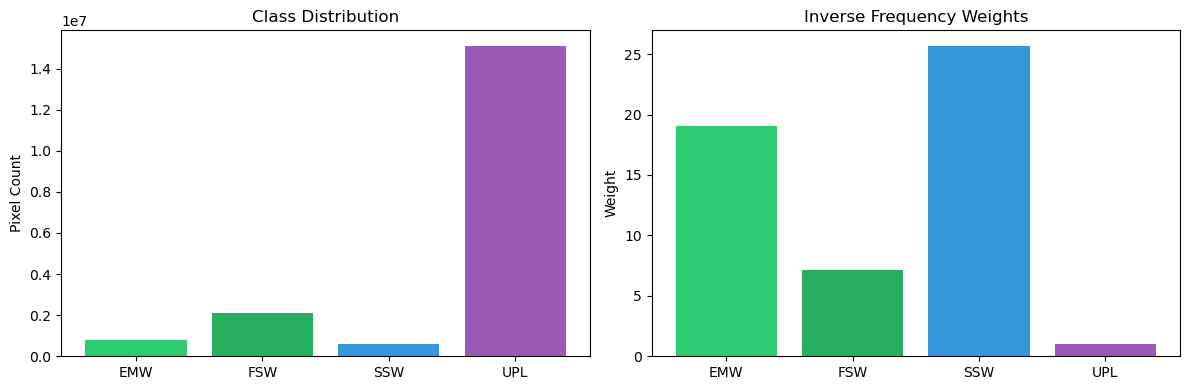

In [34]:
# Visualize class distribution
if STATS_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Class counts
    counts = [stats['class_counts'].get(name, 0) for name in CLASS_NAMES]
    # Color palette that works for both 5-class and 2-class modes
    all_colors = ['#2ecc71', '#27ae60', '#3498db', '#9b59b6', '#95a5a6']
    colors = all_colors[:NUM_CLASSES]
    
    axes[0].bar(CLASS_NAMES, counts, color=colors)
    axes[0].set_ylabel('Pixel Count')
    axes[0].set_title('Class Distribution')
    axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Class weights
    weights = [stats['class_weights'].get(name, 0) for name in CLASS_NAMES]
    axes[1].bar(CLASS_NAMES, weights, color=colors)
    axes[1].set_ylabel('Weight')
    axes[1].set_title('Inverse Frequency Weights')
    
    plt.tight_layout()
    plt.show()

## 3. Explore Data

Visualize sample patches and verify the data pipeline.

In [35]:
# Create data loaders
train_loader, val_loader, test_loader, class_weights = dataset_module.create_dataloaders(
    PATCHES_DIR, 
    STATS_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Use 0 for notebook compatibility
    seed=SEED,
)

print(f"\nClass weights: {class_weights}")

Data split (seed=420):
  Train: 199 patches (69.8%)
  Val:   42 patches (14.7%)
  Test:  44 patches (15.4%)

Class weights: tensor([19.0798,  7.1092, 25.6861,  1.0000])


In [7]:

# Get a sample batch
X_sample, y_sample = next(iter(train_loader))

in_channels = compute_in_channels_from_stats(STATS_PATH)

print(f"Input shape: {X_sample.shape} (expected: [batch, {in_channels}, 256, 256])")
print(f"Label shape: {y_sample.shape}")
print(f"Input range: [{X_sample.min():.3f}, {X_sample.max():.3f}]")
print(f"Label classes: {torch.unique(y_sample).tolist()}")


/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Input shape: torch.Size([16, 19, 256, 256]) (expected: [batch, 19, 256, 256])
Label shape: torch.Size([16, 256, 256])
Input range: [0.000, 1.000]
Label classes: [0, 1, 2, 3]


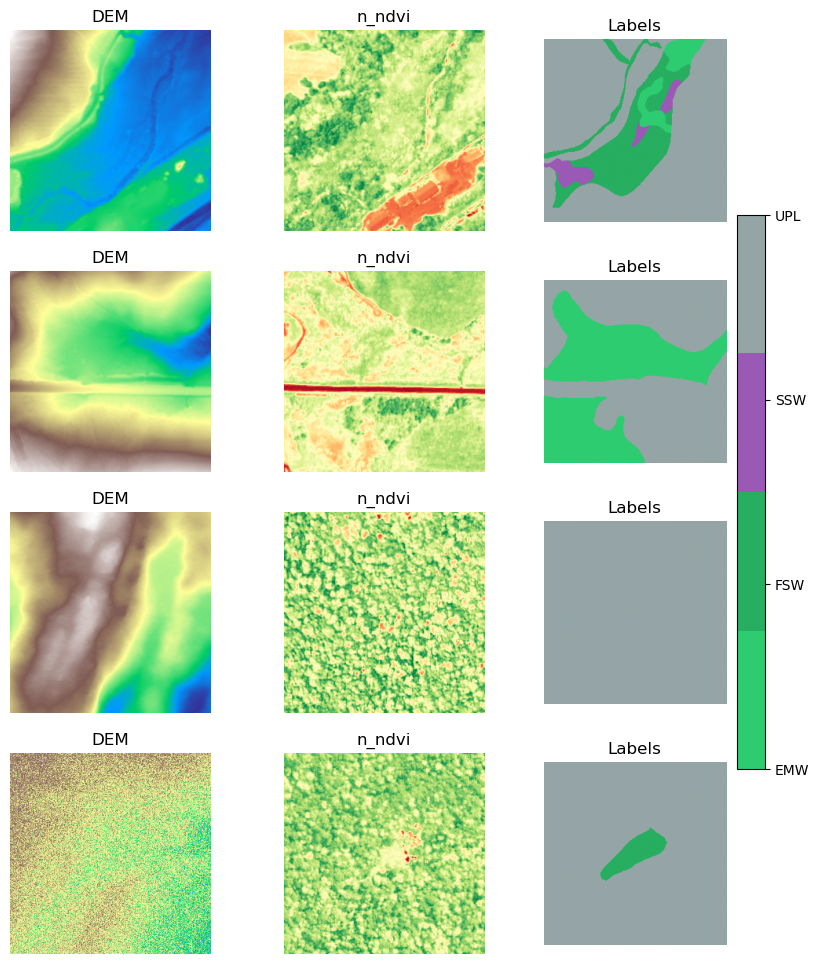

In [8]:
# Helper to find a band's channel index in the normalized tensor,
# accounting for one-hot expansion of categorical bands.
def find_band_channel(band_name, stats):
    """Return the channel index for a named band in the normalized tensor."""
    ch = 0
    for name in stats["predictor_names"]:
        method = stats["normalization"][name]["method"]
        if name == band_name:
            return ch
        if method == "one_hot":
            ch += stats["normalization"][name]["num_classes"]
        else:
            ch += 1
    raise KeyError(f"Band '{band_name}' not found in predictor_names: {stats['predictor_names']}")

# Visualize sample patches
def plot_samples(X, y, n_samples=4):
    """Plot sample patches with their labels."""
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3*n_samples))
    
    # Color map sized to actual number of classes
    all_colors = ['#2ecc71', '#27ae60', '#9b59b6', '#95a5a6']
    cmap_labels = plt.cm.colors.ListedColormap(all_colors[:NUM_CLASSES])

    # Find NDVI channel dynamically (try common names)
    ndvi_name = None
    for candidate in ["NDVI", "n_ndvi", "ndvi"]:
        if candidate in stats["predictor_names"]:
            ndvi_name = candidate
            break
    ndvi_idx = find_band_channel(ndvi_name, stats) if ndvi_name else 0
    
    for i in range(min(n_samples, X.shape[0])):
        # Use first band (DEM) for visualization
        axes[i, 0].imshow(X[i, 0].numpy(), cmap='terrain')
        axes[i, 0].set_title('DEM')
        axes[i, 0].axis('off')
        
        # NDVI visualization
        axes[i, 1].imshow(X[i, ndvi_idx].numpy(), cmap='RdYlGn')
        axes[i, 1].set_title(ndvi_name or 'Band 0')
        axes[i, 1].axis('off')
        
        # Labels
        im = axes[i, 2].imshow(y[i].numpy(), cmap=cmap_labels, vmin=0, vmax=NUM_CLASSES - 1)
        axes[i, 2].set_title('Labels')
        axes[i, 2].axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[:, 2].tolist(), shrink=0.6)
    cbar.set_ticks(range(NUM_CLASSES))
    cbar.set_ticklabels(CLASS_NAMES)
    
    # plt.tight_layout()
    plt.show()

plot_samples(X_sample, y_sample)

## 4. Train Model

Train the U-Net model on the training set.

In [9]:
# Load TensorBoard inside the notebook
# After training starts, metrics update live in the dashboard below
%load_ext tensorboard

TB_LOGDIR = str(MODELS_DIR / "tb_logs")
%tensorboard --logdir "$TB_LOGDIR" --reload_interval 30

In [28]:
from datetime import datetime
datetime.now().strftime("%Y_%m_%d_%H%M")

'2026_03_06_1306'

In [11]:
# Get training device
device = model_module.get_device()
print(f"Using device: {device}")

Using device: mps


In [12]:
# Preview model architecture (optional — training creates its own model)
in_channels = compute_in_channels_from_stats(STATS_PATH)

if ARCHITECTURE == "resunet34":
    preview_model = resunet_module.ResUNet34(
        in_channels=in_channels,
        num_classes=NUM_CLASSES,
        base_filters=BASE_FILTERS,
    ).to(device)
else:
    preview_model = model_module.create_model(
        in_channels=in_channels,
        num_classes=NUM_CLASSES,
        base_filters=BASE_FILTERS,
        depth=DEPTH,
        device=device,
    )

print(f"Architecture: {ARCHITECTURE}")
print(f"Parameters: {sum(p.numel() for p in preview_model.parameters() if p.requires_grad):,}")

Created U-Net model:
  Input channels: 19
  Output classes: 4
  Base filters: 32
  Depth: 4
  Parameters: 7,824,100
  Device: mps
Architecture: unet
Parameters: 7,824,100


In [14]:
# === RUN TRAINING (Lightning — primary) ===
history = train_module.train(
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    output_dir=MODELS_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    base_filters=BASE_FILTERS,
    depth=DEPTH,
    num_workers=0,
    seed=SEED,
    early_stopping_patience=15,
    architecture=ARCHITECTURE,
    ce_weight=CE_WEIGHT,
    dice_weight=DICE_WEIGHT,
    focal_gamma=FOCAL_GAMMA,
    label_smoothing=LABEL_SMOOTHING,
)

# === Legacy training (fallback) ===
# Uncomment below (and switch the import in cell 4) to use 04_train.py instead:
# history = train_module.train(
#     patches_dir=PATCHES_DIR,
#     stats_path=STATS_PATH,
#     output_dir=MODELS_DIR,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     learning_rate=LEARNING_RATE,
#     base_filters=BASE_FILTERS,
#     depth=DEPTH,
#     num_workers=0,
#     seed=SEED,
#     device=device,
# )

Seed set to 420


Wetland Classification Training (Lightning)
Architecture: unet
Classification mode: multiclass
Input channels: 19, Classes: 4 (['EMW', 'FSW', 'SSW', 'UPL'])
Epochs: 50, Batch size: 16, LR: 0.0001
Precision: 32-true

Data split (seed=420):
  Train: 198 patches (69.7%)
  Val:   42 patches (14.8%)
  Test:  44 patches (15.5%)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models exists and is not empty.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | net       | UNet       | 7.8 M  | train | 0    
1 | criterion | HybridLoss | 0      | train | 0    
---------------------------------------------------------
7.8 M     Trainable params
0         Non-trainable params
7.8 M     Total params
31.296    Total estimated model params size (MB)
145       Modules in train mode
0         Modules in eval mode
0         Total Flops


Class weights: [19.07979965209961, 7.1092000007629395, 25.686100006103516, 1.0]
Sanity Checking: |                                                                                | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Impacting Interactivity (0000000e:kIOGPUCommandBufferCallbackErrorImpactingInteractivity)
	<AGXG13XFamilyCommandBuffer: 0x34bc49f80>
    label = <none> 
    device = <AGXG13XDevice: 0x32400dc00>
        name = Apple M1 Max 
    commandQueue = <AGXG13XFamilyCommandQueue: 0x311509000>
        label = <none> 
        device = <AGXG13XDevice: 0x32400dc00>
            name = Apple M1 Max 
    retainedReferences = 1


Epoch 2: 100%|█| 13/13 [00:23<00:00,  0.55it/s, v_num=2232, val/loss=3.080, val/acc=0.019, val/iou=0.000, train/loss=3.7
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|████████████████████████████████████████████████████████████| 3/3 [00:07<00:00,  0.40it/s]
Epoch 3:  54%|▌| 7/13 [00:21<00:18,  0.33it/s, v_num=2232, val/loss=3.000, val/acc=0.0449, val/iou=0.0379, train/loss=3.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [10]:
with open(PROJECT_ROOT / f"Models/training_history_{CLASSIFICATION_MODE}_{ARCHITECTURE}.json", 'r') as file:
        history = json.load(file)

f"Models/training_history_{CLASSIFICATION_MODE}_{ARCHITECTURE}.json"

'Models/training_history_multiclass_unet.json'

In [17]:
history["train_iou"]

[]

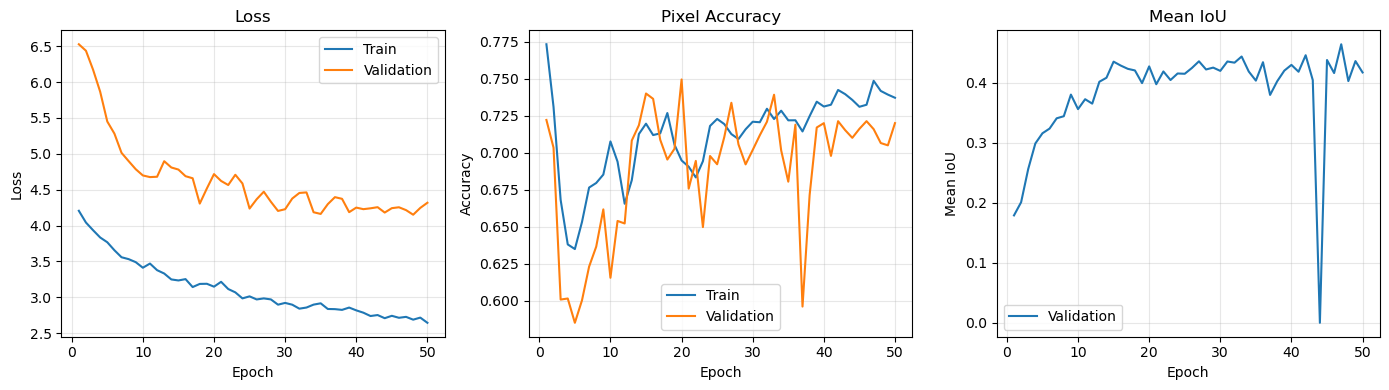

In [18]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_accuracy'], label='Train')
axes[1].plot(epochs_range, history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Pixel Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# IoU
# axes[2].plot(epochs_range, history['train_iou'], label='Train')
axes[2].plot(epochs_range, history['val_iou'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Mean IoU')
axes[2].set_title('Mean IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / f'training_curves{MODE_SUFFIX}.png', dpi=150)
plt.show()

## 5. Evaluate Model

Evaluate the best model on the held-out test set.

In [24]:
# Load best model and create test loader (calls 05_evaluate.py)
device = model_module.get_device()
in_channels = compute_in_channels_from_stats(STATS_PATH)

# Recreate test loader (same seed = same split)
_, _, test_loader, _ = dataset_module.create_dataloaders(
    PATCHES_DIR, STATS_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Use 0 for notebook compatibility
    seed=SEED,
)

model = eval_module.load_model(
    MODELS_DIR / f'best_{CLASSIFICATION_MODE}_{ARCHITECTURE}-v12.ckpt',
    device=device,
    in_channels=in_channels,
    num_classes=NUM_CLASSES,
    base_filters=BASE_FILTERS,
    depth=DEPTH,
    architecture=ARCHITECTURE,
)

# Legacy checkpoint (fallback):
# model = eval_module.load_model(
#     MODELS_DIR / f'best_model{MODE_SUFFIX}.pth',
#     device=device,
#     in_channels=in_channels,
#     num_classes=NUM_CLASSES,
#     base_filters=BASE_FILTERS,
#     depth=DEPTH
# )

Data split (seed=420):
  Train: 199 patches (69.8%)
  Val:   42 patches (14.7%)
  Test:  44 patches (15.4%)
Loaded model from /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/best_multiclass_unet-v12.ckpt
  Epoch: 4


In [21]:
# Evaluate on test set (calls 05_evaluate.py)
metrics = eval_module.evaluate(
    model, test_loader, device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    class_names=CLASS_NAMES
)

eval_module.print_metrics(metrics, CLASS_NAMES)

Running inference...


/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


  Total pixels: 2,883,584, Labeled: 2,883,584, Unlabeled: 0
Computing metrics...

Evaluation Results

Overall Accuracy: 0.7352
Mean IoU: 0.3690
Macro F1: 0.5073

Per-Class Metrics:
------------------------------------------------------------
Class         Precision     Recall         F1        IoU    Support
------------------------------------------------------------
EMW              0.3741     0.6600     0.4775     0.3136    106,220
FSW              0.3023     0.7768     0.4352     0.2781    250,956
SSW              0.1734     0.6826     0.2765     0.1604     48,304
UPL              0.9790     0.7352     0.8398     0.7239  2,478,104
------------------------------------------------------------

Confusion Matrix:
                 EMW     FSW     SSW     UPL
EMW           70,104   1,988  31,662   2,466
FSW            5,636 194,951  18,991  31,378
SSW            8,804   1,379  32,970   5,151
UPL          102,864 446,660 106,5561,822,024


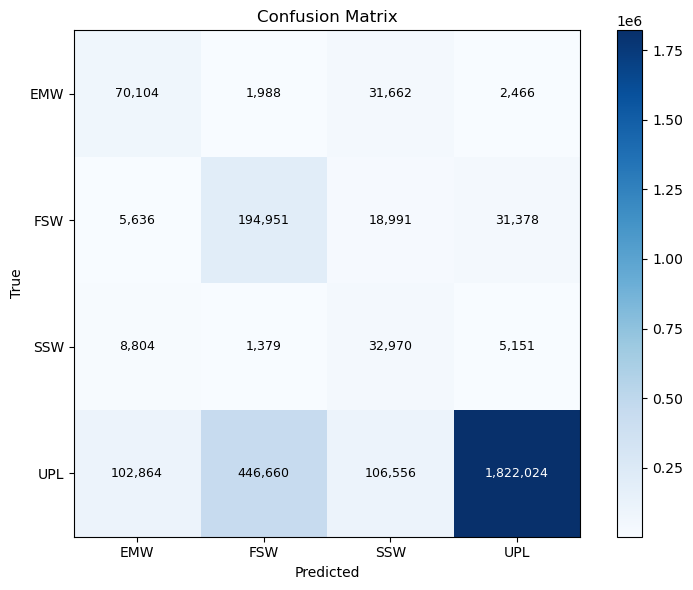

In [22]:
# Plot confusion matrix
cm = np.array(metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

# Add text annotations
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val = cm[i, j]
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, f'{val:,}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.savefig(MODELS_DIR / f'confusion_matrix{MODE_SUFFIX}.png', dpi=150)
plt.show()

/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


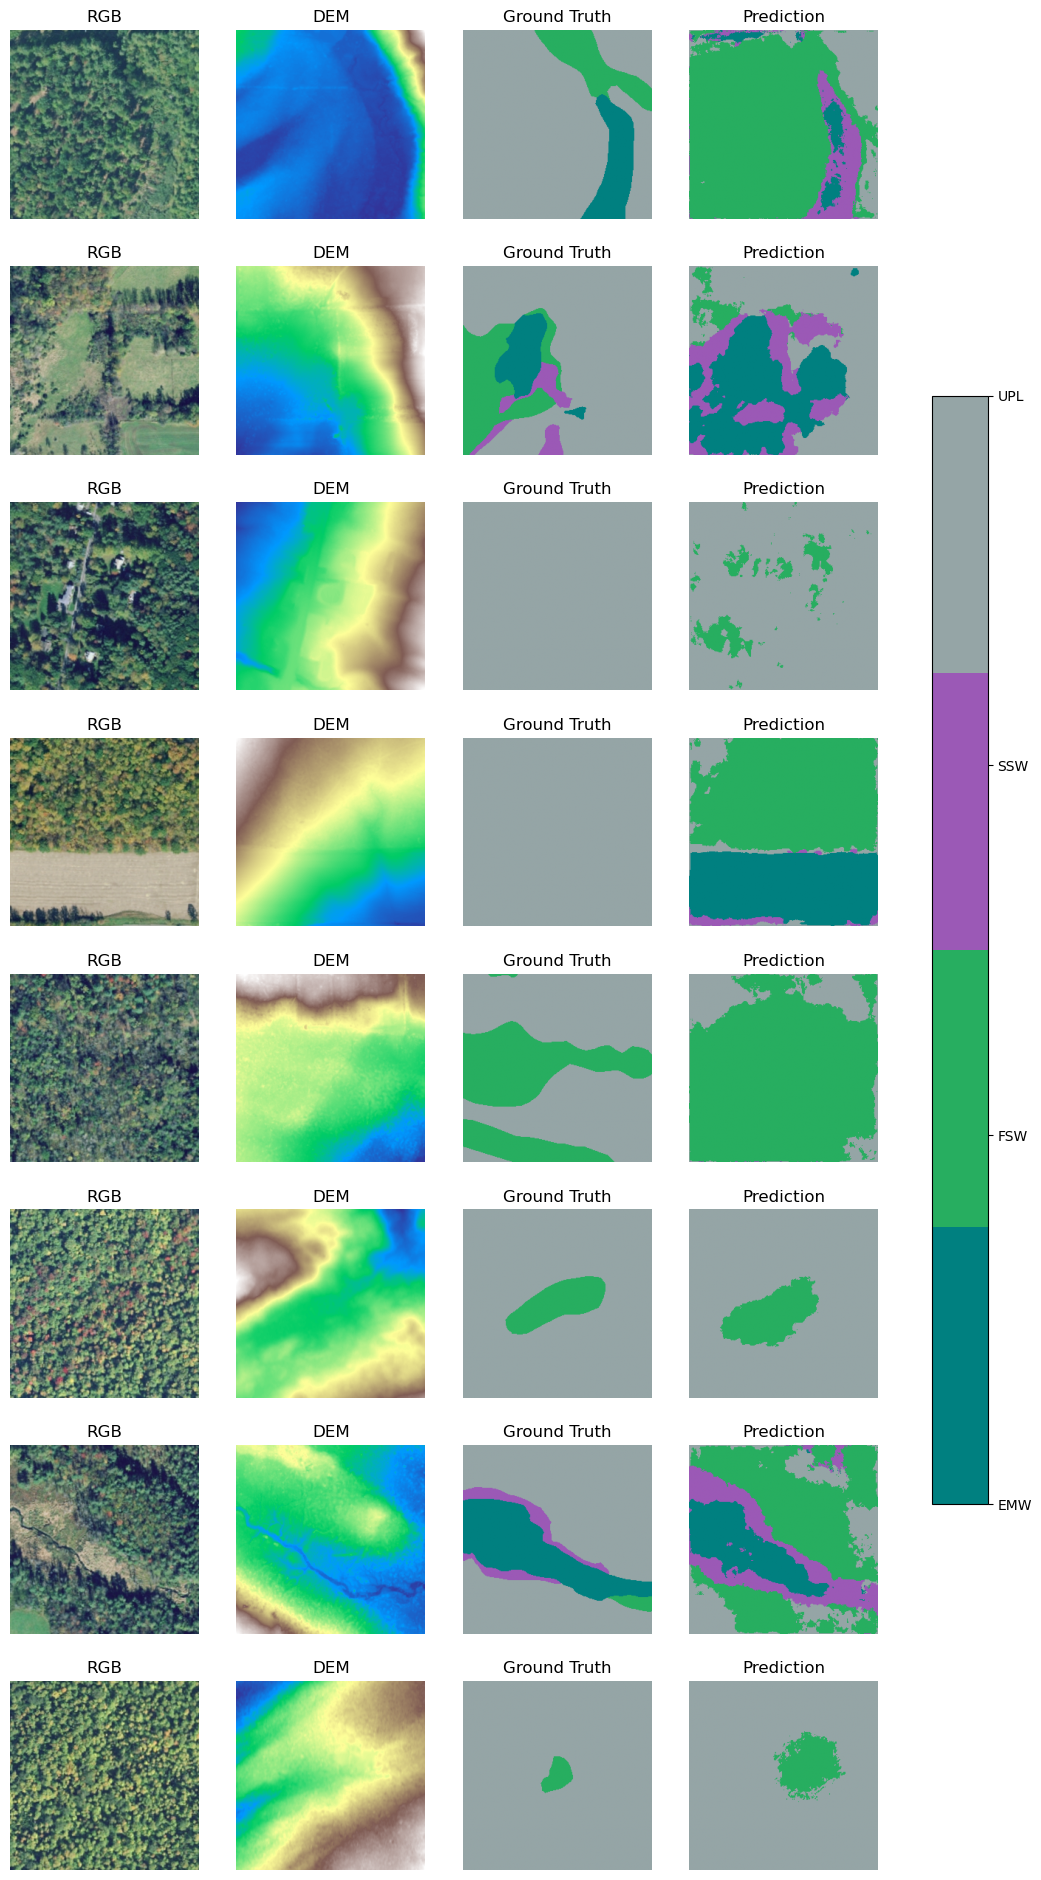

In [23]:
# Visualize predictions on test samples
X_test, y_test = next(iter(test_loader))
X_test_dev = X_test.to(device)

with torch.no_grad():
    preds = model(X_test_dev).argmax(dim=1).cpu()

# Find RGB channel indices dynamically
rgb_indices = [find_band_channel(name, stats) for name in ("r", "g", "b")]

# Plot: RGB | DEM | Ground Truth | Prediction
n_samples = 8
fig, axes = plt.subplots(n_samples, 4, figsize=(14, 3 * n_samples))
all_colors = ['#008080', '#27ae60', '#9b59b6', '#95a5a6']
cmap = plt.cm.colors.ListedColormap(all_colors[:NUM_CLASSES])

for i in range(n_samples):
    # RGB composite (already normalized to [0, 1])
    rgb = X_test[i, rgb_indices].numpy().transpose(1, 2, 0)
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title('RGB')
    axes[i, 0].axis('off')

    # DEM
    axes[i, 1].imshow(X_test[i, 0].cpu().numpy(), cmap='terrain')
    axes[i, 1].set_title('DEM')
    axes[i, 1].axis('off')

    # Ground truth
    axes[i, 2].imshow(y_test[i].numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title('Ground Truth')
    axes[i, 2].axis('off')

    # Prediction
    im = axes[i, 3].imshow(preds[i].numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 3].set_title('Prediction')
    axes[i, 3].axis('off')

# Legend
cbar = plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASS_NAMES)

# plt.tight_layout()
plt.savefig(MODELS_DIR / f'test_predictions{MODE_SUFFIX}.png', dpi=150)
plt.show()

## 6. Predict on New Rasters

Apply the trained model to full rasters.

In [ ]:
# Import prediction module
predict_module = import_module("predict", SCRIPT_DIR / "06_predict.py")

In [ ]:
# === Configure prediction ===
# Set the input raster path (must have 20+ bands in correct order)
INPUT_RASTER = PROJECT_ROOT / "Data/HUC_DL_Stacks/cluster_64_huc_041300030201_stack.tif"  # <-- EDIT THIS
OUTPUT_RASTER = PROJECT_ROOT / "Data/HUC_DL_Predictions/cluster_64_huc_041300030201_DL_predict_v3.tif"

# Prediction settings
PATCH_SIZE = 256
OVERLAP = 128  # Overlap for smoother predictions
SAVE_PROBS = True  # Save probability maps

In [ ]:
# Run prediction
predict_module.main(
    model_path=MODELS_DIR / f'best_{CLASSIFICATION_MODE}_{ARCHITECTURE}.ckpt',
    input_path=INPUT_RASTER,
    output_path=OUTPUT_RASTER,
    stats_path=STATS_PATH,
    patch_size=PATCH_SIZE,
    overlap=OVERLAP,
    base_filters=BASE_FILTERS,
    depth=DEPTH,
    save_probabilities=SAVE_PROBS,
    architecture=ARCHITECTURE,
)

# Legacy checkpoint (fallback):
# predict_module.main(
#     model_path=MODELS_DIR / f'best_model{MODE_SUFFIX}.pth',
#     ...
# )

## Summary

This notebook provides an interactive interface to:
1. Compute normalization statistics from training data
2. Explore and visualize the data
3. Train a U-Net model with class weighting
4. Evaluate on a held-out test set
5. Generate predictions on new rasters

### Files Generated

Model and output files include a mode suffix (`_multiclass` or `_binary`) so both modes can coexist:

- `Data/Training_Data/normalization_stats.json` - Band statistics and class weights
- `Models/best_model_{mode}.pth` - Best model checkpoint
- `Models/final_model_{mode}.pth` - Final model checkpoint  
- `Models/training_history_{mode}.json` - Training metrics
- `Models/training_curves_{mode}.png` - Loss/accuracy plots
- `Models/confusion_matrix_{mode}.png` - Confusion matrix visualization
- `Models/test_predictions_{mode}.png` - Sample predictions